In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [2]:
# Upload Iris dataset
uploaded = files.upload()

data = pd.read_csv("Iris.csv")
print(data.head())

Saving Iris.csv to Iris.csv
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [3]:
print("\nColumns (Features):", list(data.columns))
print("Number of Rows (Samples):", data.shape[0])
print("Target Variable: Species")


Columns (Features): ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
Number of Rows (Samples): 150
Target Variable: Species


In [4]:
label_encoder = LabelEncoder()
data['species_encoded'] = label_encoder.fit_transform(data['Species'])

# Check encoding
print(data[['Species', 'species_encoded']].drop_duplicates())

             Species  species_encoded
0        Iris-setosa                0
50   Iris-versicolor                1
100   Iris-virginica                2


In [5]:
print("Missing values in each column:")
print(data.isnull().sum())

# Handle missing values using MEDIAN (for demonstration)
data.fillna(data.median(numeric_only=True), inplace=True)

Missing values in each column:
Id                 0
SepalLengthCm      0
SepalWidthCm       0
PetalLengthCm      0
PetalWidthCm       0
Species            0
species_encoded    0
dtype: int64


In [6]:
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = data['species_encoded']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [8]:
# Create and train the Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
# Training performance
y_train_pred = dt.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred, average='macro')
train_rec = recall_score(y_train, y_train_pred, average='macro')

print("Training Performance:")
print(f"Accuracy: {train_acc:.2f}, Precision: {train_prec:.2f}, Recall: {train_rec:.2f}")

# Testing performance
y_test_pred = dt.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average='macro')
test_rec = recall_score(y_test, y_test_pred, average='macro')

print("\nTesting Performance:")
print(f"Accuracy: {test_acc:.2f}, Precision: {test_prec:.2f}, Recall: {test_rec:.2f}")

Training Performance:
Accuracy: 1.00, Precision: 1.00, Recall: 1.00

Testing Performance:
Accuracy: 0.93, Precision: 0.93, Recall: 0.93


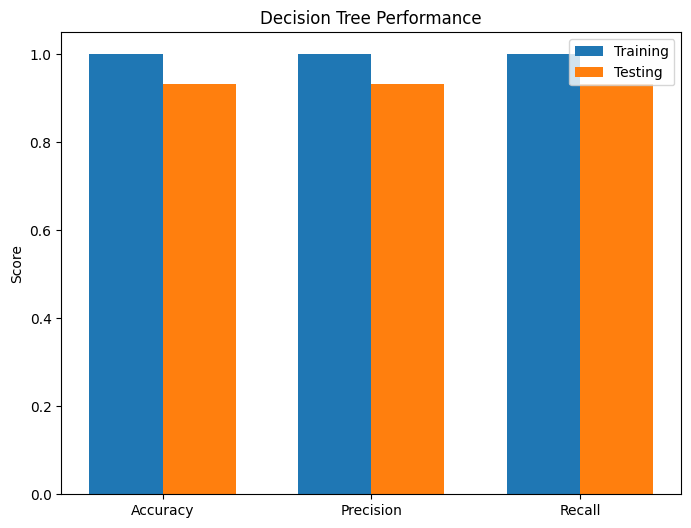

In [10]:
metrics = ['Accuracy', 'Precision', 'Recall']
training_scores = [train_acc, train_prec, train_rec]
testing_scores = [test_acc, test_prec, test_rec]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(x - width/2, training_scores, width, label='Training')
ax.bar(x + width/2, testing_scores, width, label='Testing')

ax.set_ylabel('Score')
ax.set_title('Decision Tree Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.show()

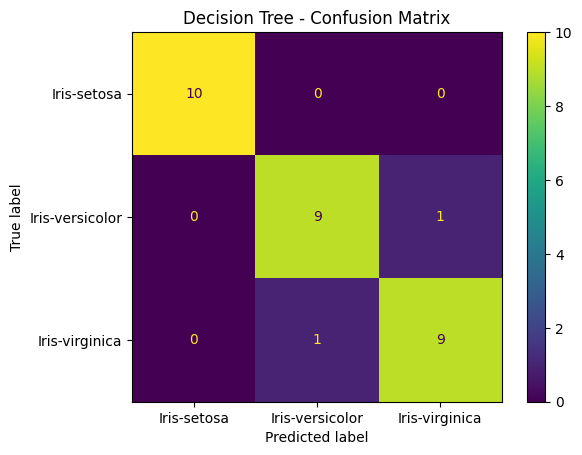

In [11]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

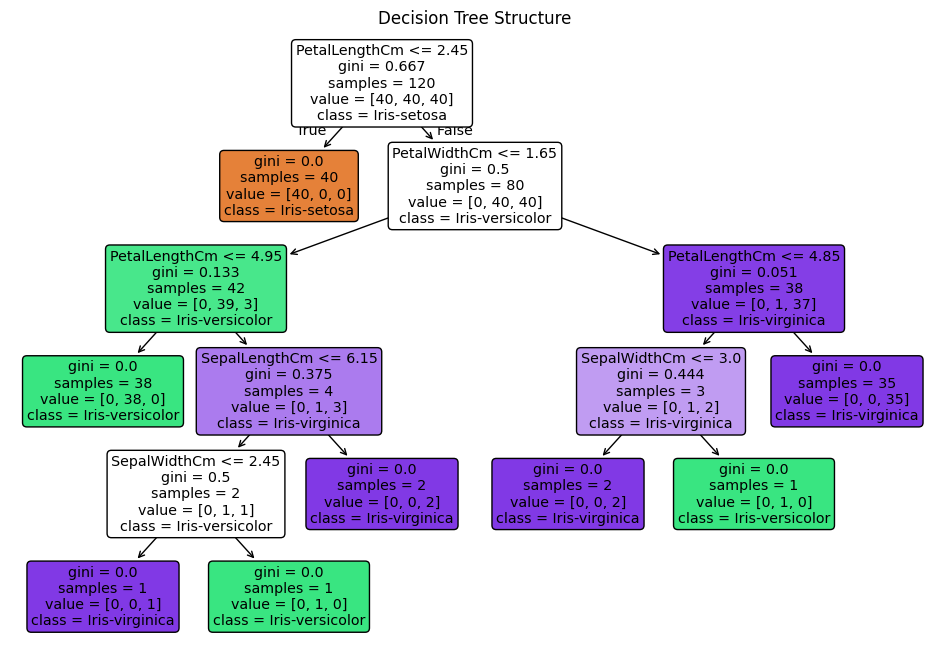

In [12]:
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=label_encoder.classes_, filled=True, rounded=True)
plt.title("Decision Tree Structure")
plt.show()

In [13]:
# Example new sample
new_sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=X.columns)

# Predict
prediction = dt.predict(new_sample)[0]
predicted_class = label_encoder.inverse_transform([prediction])[0]

print("New Sample:", new_sample.values)
print("Predicted Class:", predicted_class)

New Sample: [[5.1 3.5 1.4 0.2]]
Predicted Class: Iris-setosa


In [15]:
# Trace decision path
node_indicator = dt.decision_path(new_sample)
leaf_id = dt.apply(new_sample)

print("Node indices along the path:", node_indicator.indices)
print("Leaf node where sample ends up:", leaf_id)

Node indices along the path: [0 1]
Leaf node where sample ends up: [1]


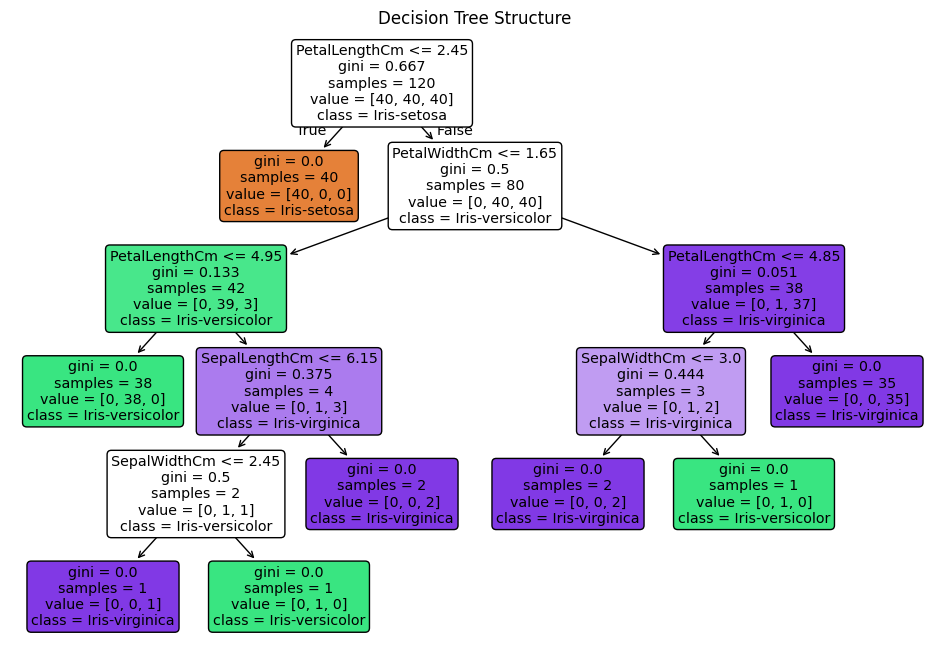

In [16]:
plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure")
plt.show()